<hr><h1><b><u>Import Libraries</u></h1></b>

In [71]:
import numpy as np 
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

<hr><h1><b><u>Load Dataset</u></b></h1>

In [72]:
df = pd.read_csv('cleaned_dataset.csv')

<hr><h1><b><u>Explore Data</u></b></h1>

In [73]:
display(df.head())

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,male,asian,highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,female,white,highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,NaN,0
2,60,male,hispanic,highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,female,black,highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,male,white,graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [74]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

None

In [75]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
diet_score,97297.0,5.995214,1.780096,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,97297.0,6.997708,1.093726,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,97297.0,0.219657,0.414017,0.00,0.00,0.00,0.00,1.00
hypertension_history,97297.0,0.250912,0.433540,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,97297.0,0.079067,0.269845,0.00,0.00,0.00,0.00,1.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20


<hr><b><h1><u>Visualisations

<h2>Distribution of diabetes stages</h2>

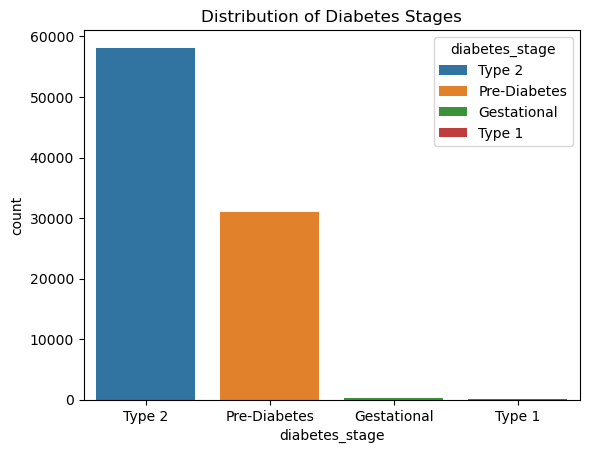

In [76]:
sns.countplot(x='diabetes_stage', data=df, hue = 'diabetes_stage')
plt.title('Distribution of Diabetes Stages')
plt.show()

<h2>Distribution of diagnosed diabetes </h2>

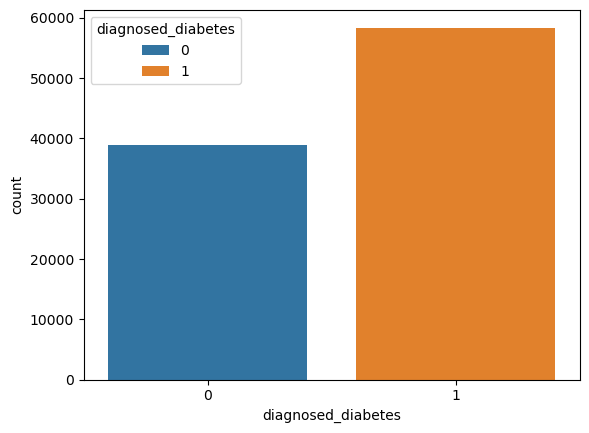

In [101]:
sns.countplot(x='diagnosed_diabetes', data=df, hue='diagnosed_diabetes')
plt.show()

<h2> Count of BMI, Age, hba1c, Physical Activity</h2>

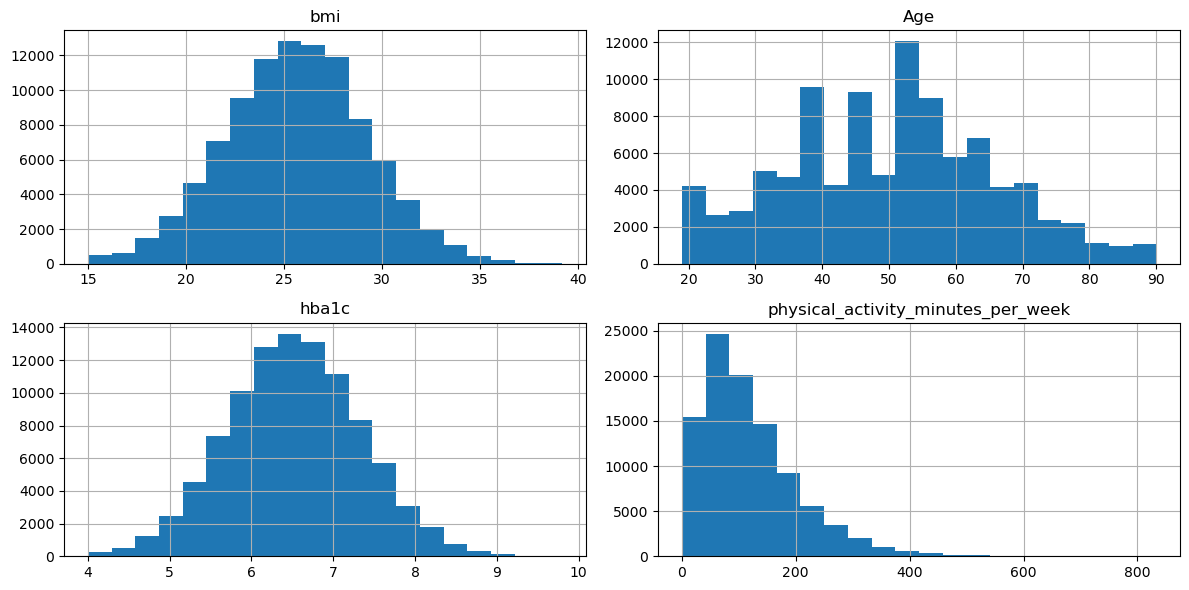

In [78]:
df[['bmi', 'Age', 'hba1c', 'physical_activity_minutes_per_week']].hist(bins=20, figsize=(12,6))
plt.tight_layout()
plt.show()

<h2>Box plot - BMI vs Diabetes Stage</h2>

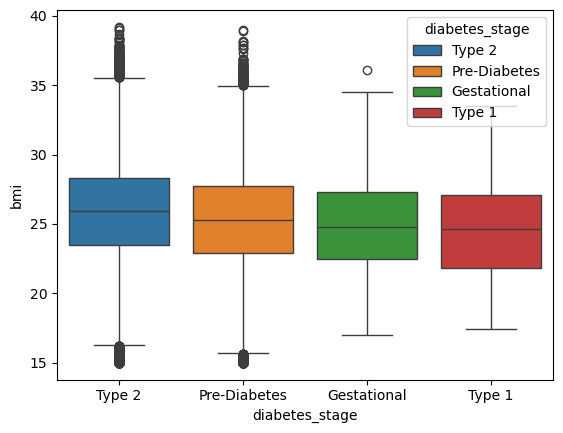

In [93]:
sns.boxplot(x='diabetes_stage', y='bmi', data=df, hue='diabetes_stage')
plt.show()

<b>Findings</b>
<p>People with a higher bmi tend to be more prone to diabetes, especially with regards to Type 2 diabetes and the Pre-Diabetes stage.

<h2>Box plot - Total Cholesterol vs Diabetes Stage</h2>

<Axes: xlabel='diabetes_stage', ylabel='cholesterol_total'>

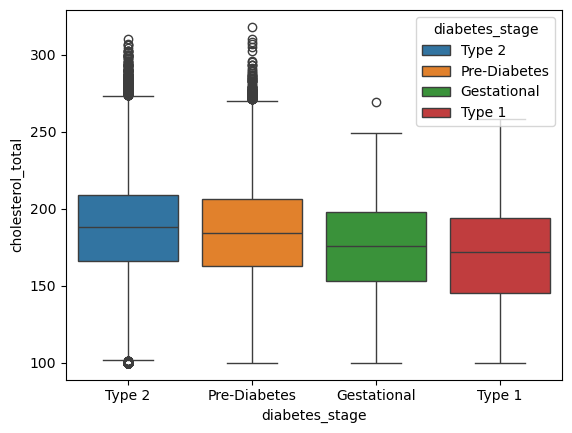

In [80]:
sns.boxplot(x='diabetes_stage', y='cholesterol_total', data=df, hue='diabetes_stage')

<b>Findings</b>
<p>People with a higher total cholesterol are prone to Type 2 Diabetes and the Pre-Diabetes stage. With some cases of people having low total cholesterol and Type 2 Diabetes

<h2>Bar plot - Age vs Diabetes Stage</h2>

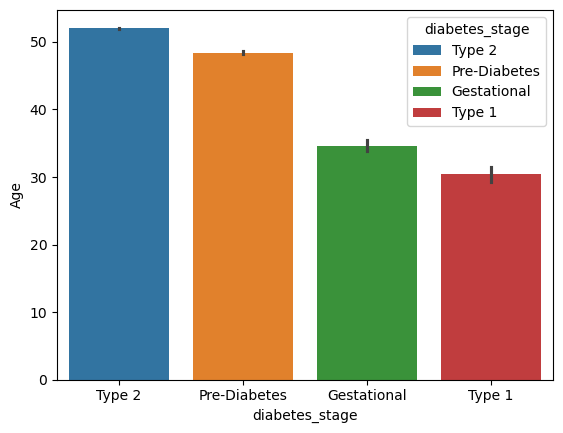

In [95]:
sns.barplot(x='diabetes_stage',y='Age', data=df, hue = 'diabetes_stage')
plt.show()

<b>Findings</b>
<p>Age shows a clear upward trend with diabetes severity. Older individuals are more likely to fall into the Pre-Diabetes and Type 2 Diabetes categories, indicating age as a strong risk factor.

<h2>Box plot - Physical Activity vs Diabetes Stage</h2>

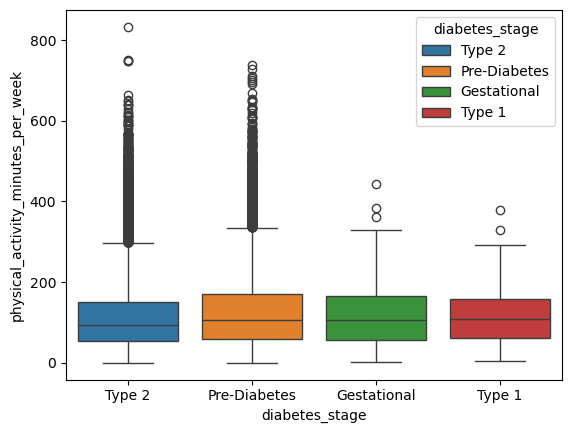

In [96]:
sns.boxplot(x='diabetes_stage', y='physical_activity_minutes_per_week', data=df, hue='diabetes_stage')
plt.show()

<b>Findings</b>
<p>Individuals with lower physical activity levels tend to fall into Pre-Diabetes and Type 2 Diabetes groups. Higher activity levels are more common among non-diabetic individuals, suggesting physical activity plays a protective role.</p>

<h2>Age distribution per diabetes stage</h2>

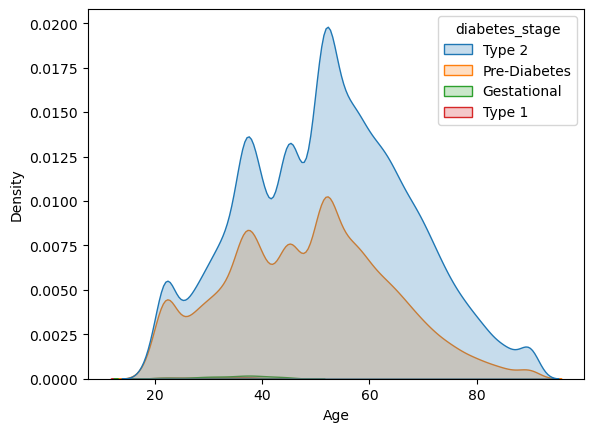

In [98]:
sns.kdeplot(data=df, x='Age', hue='diabetes_stage', fill=True)
plt.show()

<b>Findings</b>
<p>The distribution shows that non-diabetic individuals are generally younger, while Pre-Diabetic and Type 2 groups are skewed toward older age ranges. This reinforces the relationship between increasing age and diabetes risk.</p>

<h2>Insulin level per diabetes stage by Gender</h2>

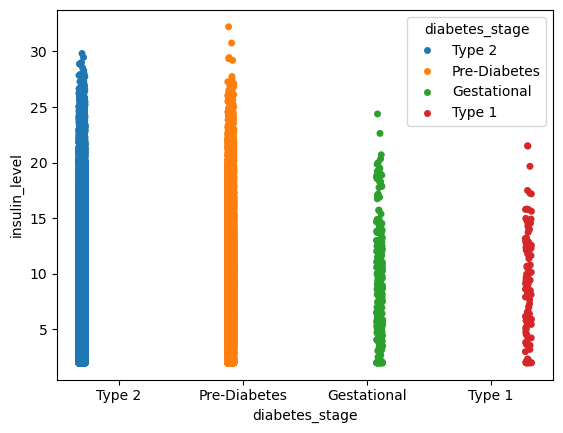

In [85]:
sns.stripplot(x='diabetes_stage', y='insulin_level', hue='diabetes_stage', data=df, dodge=True)
plt.show()

<b>Findings</b>
<p>Insulin levels tend to be higher and more variable in individuals with Type 2 Diabetes</p>

<H1>Findings</h1>

<p>The visualisations reveal that diabetes risk is influenced by a combination of lifestyle and biological factors. Higher BMI and cholesterol levels are strongly associated with increased diabetes severity, particularly Type 2 Diabetes. Age is another major contributor, with older individuals showing significantly higher risk.

Lifestyle factors, especially physical activity, play a critical protective role. Individuals who engage in more weekly physical activity are less likely to develop severe forms of diabetes. Additionally, insulin levels become more irregular and elevated as diabetes progresses, indicating worsening metabolic function.